# U-Net: Convolutional Networks for Biomedical Image Segmentation

Based from [Miltos-90](https://github.com/Miltos-90)
Please checkout also [Pytorch-UNet0](https://github.com/milesial/Pytorch-UNet0)

## Overview

In the following we will implement Unet in pytorch and train on the dataset used by the authors of [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://link.springer.com/chapter/10.1007%2F978-3-319-24574-4_28)

### Libraries

In [ ]:
!pip install timer tqdm

In [ ]:
from collections import defaultdict
import numpy as np
import cv2
import os
from PIL import Image
from torchvision.transforms import v2 as T

import os
import numpy as np
import matplotlib.pyplot as plt

import albumentations as A
import gc
from tqdm.notebook import tqdm
from timeit import default_timer as timer

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim


In [ ]:
torch.multiprocessing.set_start_method('spawn')

## Unet Implementation

The architecture of the model is the following:


It consists of a contracting path (left side) and an expansive path (right side). The constrasting path follows the typical architecture of a convolutional neural network, and it consists of the repeated
application of two 3x3 convolutions (unpadded convolutions), each followed by
a rectified linear unit (ReLU) and a 2x2 max pooling operation with stride 2
for downsampling. At each downsampling step we double the number of feature
channels. Every step in the expansive path consists of an upsampling of the
feature map followed by a 2x2 convolution (“up-convolution”) that halves the
number of feature channels, a concatenation with the correspondingly cropped
feature map from the contracting path, and two 3x3 convolutions, each followed by a ReLU. The cropping is necessary due to the loss of border pixels in
every convolution. At the final layer a 1x1 convolution is used to map each 64-
component feature vector to the desired number of classes. In total the network
has 23 convolutional layers.

Let's make sure that the implementation works. We'll check if the output dimensions of the tensors match the ones mentioned in Figure 1 when using the same architecture and same size inputs

In [ ]:
class UNetSegmentation(nn.Module):
    """
    U-Net neural network for image segmentation.

    Args:
        in_channels (int): Number of input channels (e.g., 16 for your patches)

    The U-Net consists of an encoder (downsampling), a bottleneck (middle),
    and a decoder (upsampling). It is widely used for segmenting images,
    where every pixel needs to be classified (e.g., rain/no rain).
    """
    def __init__(self, in_channels, no_classes):
        super().__init__()
        # Encoder path ("contracting" path): extracts features, reduces size
        self.encoder1 = self.conv_block(in_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)  # Downsamples by factor of 2

        # Bottleneck (middle part)
        self.mid = self.conv_block(512, 1024)

        # Decoder path ("expanding" path): upscales, combines with encoder outputs
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)  # Upsample
        self.dec4 = self.conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = self.conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self.conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = self.conv_block(128, 64)

        # Final layer: reduces to 1 output channel per pixel (for binary segmentation)
        self.final = nn.Conv2d(64, no_classes, kernel_size=1)  # Output: logits per pixel

    def conv_block(self, in_ch, out_ch):
        """
        Helper function to build a block of two convolutional layers,
        each followed by BatchNorm and ReLU activation.

        Args:
            in_ch (int): Number of input channels.
            out_ch (int): Number of output channels.
        """
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),   # Keeps spatial size the same
            nn.BatchNorm2d(out_ch),                   # Helps training
            nn.ReLU(inplace=True),                    # Non-linearity
            nn.Conv2d(out_ch, out_ch, 3, padding=1),  # Another conv layer
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x (torch.Tensor): Input tensor of shape [batch, channels, height, width]

        Returns:
            torch.Tensor: Output logits, shape [batch, 1, height, width]
        """
        # Encoder: save outputs for skip connections
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))
        m = self.mid(self.pool(e4))

        # Decoder: upsample, concatenate with encoder outputs (skip connections), then convolve
        d4 = self.dec4(torch.cat([self.up4(m), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)  # Output shape: [batch, 1, H, W]

In [ ]:
x   = torch.Tensor(np.random.rand(2, 3, 512, 512))
net = UNetSegmentation(in_channels = 3, no_classes = 4)
x   = net(x)
print(x.shape)

x   = torch.Tensor(np.random.rand(2, 3, 256, 256))
net = UNetSegmentation(in_channels = 3, no_classes = 2)
x   = net(x)
print(x.shape)

x   = torch.Tensor(np.random.rand(3, 1, 128, 128))
net = UNetSegmentation(in_channels = 1, no_classes = 1)
x   = net(x)
print(x.shape)

del x, net
gc.collect();

torch.Size([2, 4, 512, 512])
torch.Size([2, 2, 256, 256])
torch.Size([3, 1, 128, 128])


In [ ]:
def readData(datadir, labeldir, H = 512, W = 512):
    img_mtrx  = np.empty(shape = (30, H, W), dtype = np.uint8)
    mask_mtrx = np.empty(shape = (30, H, W))

    # Loop over all image / mask pairs
    for i, (img, lab) in enumerate(zip(os.listdir(datadir), os.listdir(labeldir))):

        # Load image
        image = np.array(Image.open(datadir + img))

        # Add channel dimension
        image = np.expand_dims(image, axis = 0)

        # Add to matrix
        img_mtrx[i, :, :] = image

        # Load mask in grayscale (single channel)
        mask = cv2.imread(labeldir + lab, cv2.IMREAD_GRAYSCALE)

        # Binarise
        _, mask = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)

        # Add to matrix
        mask_mtrx[i, :, :] = mask

    return img_mtrx, mask_mtrx

def weight_map(mask, w0, sigma, background_class = 0):

    # Fix mask datatype (should be unsigned 8 bit)
    if mask.dtype != 'uint8':
        mask = mask.astype('uint8')

    # Weight values to balance classs frequencies
    wc = _class_weights(mask)

    # Assign a different label to each connected region of the image
    _, regions = cv2.connectedComponents(mask)

    # Get total no. of connected regions in the image and sort them excluding background
    region_ids = sorted(np.unique(regions))
    region_ids = [region_id for region_id in region_ids if region_id != background_class]

    if len(region_ids) > 1: # More than one connected regions

        # Initialise distance matrix (dimensions: H x W x no.regions)
        distances = np.zeros((mask.shape[0], mask.shape[1], len(region_ids)))

        # For each region
        for i, region_id in enumerate(region_ids):

            # Mask all pixels belonging to a different region
            m = (regions != region_id).astype(np.uint8)# * 255

            # Compute Euclidean distance for all pixels belongind to a different region
            distances[:, :, i] = cv2.distanceTransform(m, distanceType = cv2.DIST_L2, maskSize = 0)

        # Sort distances w.r.t region for every pixel
        distances = np.sort(distances, axis = 2)

        # Grab distance to the border of nearest region
        d1, d2 = distances[:, :, 0], distances[:, :, 1]

        # Compute RHS of weight map and mask background pixels
        w = w0 * np.exp(-1 / (2 * sigma ** 2)  * (d1 + d2) ** 2) * (regions == background_class)

    else: # Only a single region present in the image
        w = np.zeros_like(mask)

    # Instantiate a matrix to hold class weights
    wc_x = np.zeros_like(mask)

    # Compute class weights for each pixel class (background, etc.)
    for pixel_class, weight in wc.items():

        wc_x[mask == pixel_class] = weight

    # Add them to the weight map
    w = w + wc_x

    return w

def _class_weights(mask):
    ''' Create a dictionary containing the classes in a mask,
        and their corresponding weights to balance their occurence
    '''

    wc = defaultdict()

    # Grab classes and their corresponding counts
    unique, counts = np.unique(mask, return_counts = True)

    # Convert counts to frequencies
    counts = counts / np.prod(mask.shape)

    # Get max. counts
    max_count = max(counts)

    for val, count in zip(unique, counts):
        wc[val] = max_count / count

    return wc



## Training on the 2012 EM Segmentation Challenge

A test case example of the paper was the [ISBI 2012 challenge](http://brainiac2.mit.edu/isbi_challenge/). This dataset contains 30 ssTEM (serial section Transmission Electron Microscopy) 512x512 images taken from the Drosophila larva ventral nerve cord (VNC). The images represent a set of consecutive slices within one 3D volume. The microcube measures 2 x 2 x 1.5 microns approx., with a resolution of 4x4x50 nm/pixel.

The corresponding binary labels are provided in an in-out fashion, i.e. white for the pixels of segmented objects and black for the rest of pixels (which correspond mostly to membranes).

30 512x512 images of 1 channel can easily fit to memory, so we can load the entire dataset once.
Let's read the data and visualise an example:

In [ ]:
!git clone https://github.com/hoangp/isbi-datasets.git

Cloning into 'isbi-datasets'...
remote: Enumerating objects: 105, done.
remote: Total 105 (delta 0), reused 0 (delta 0), pack-reused 105 (from 1)
Receiving objects: 100% (105/105), 35.19 MiB | 32.03 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [ ]:
!mv isbi-datasets/data .

In [ ]:
!ls

data  isbi-datasets


In [ ]:
datadir  = './data/images/'
labeldir = './data/labels/'

# Channel and image dimensions (from the data decription)
C, H, W = 1, 512, 512

img_mtrx, mask_mtrx = readData(datadir, labeldir)

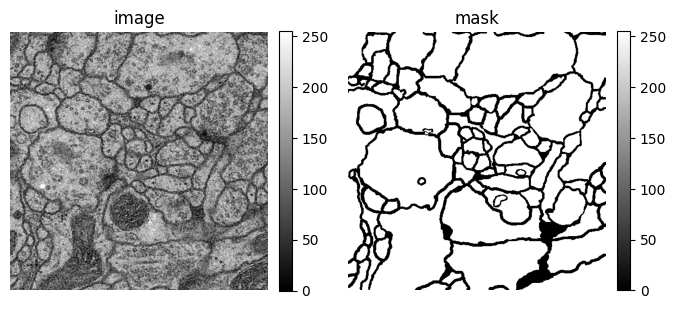

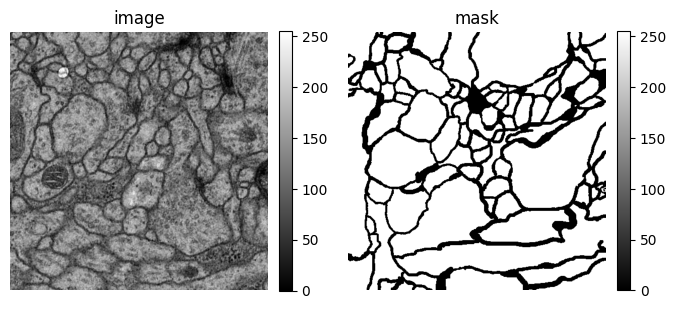

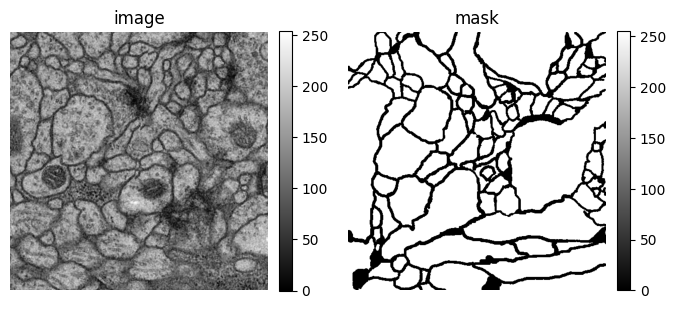

In [ ]:
# Plot a few examples
for i in [1, 5, 10]:
    fig, ax = plt.subplots(1, 2, figsize = (8, 8))

    im = ax[0].imshow(img_mtrx[i, :, :], 'gray')
    plt.colorbar(im, ax = ax[0], fraction = 0.046, pad = 0.04)
    ax[0].axis('off')
    ax[0].set_title('image')

    im = ax[1].imshow(mask_mtrx[i, :, :], 'gray')
    plt.colorbar(im, ax = ax[1], fraction = 0.046, pad = 0.04)
    ax[1].axis('off')
    ax[1].set_title('mask')

## Weight map

Authors precompute the weight map for each ground truth segmentation to compensate the different frequency of pixels from a certain class in the training dataset, in order to force the network to learn the small separation borders that they introduce between touching cells.
The separation border is computed using morphological operations, and subsequently the weight map is the computed as:

$w(\mathbf{x}) = w_c(\mathbf{x}) + w_0 \exp \left( - \frac{\left[ d_1(x) + d_2(x)\right]^2}{2\sigma^2} \right) $

where $w_c: \Omega \rightarrow \mathbb{R}$ is the weight map to balance the class fequencies, $d_1:\Omega \rightarrow \mathbb{R}$ is the distance to the border of the nearest cell, and  $d_2:\Omega \rightarrow \mathbb{R}$ is the distance to the border of the second nearest cell.

Let's check a few examples:

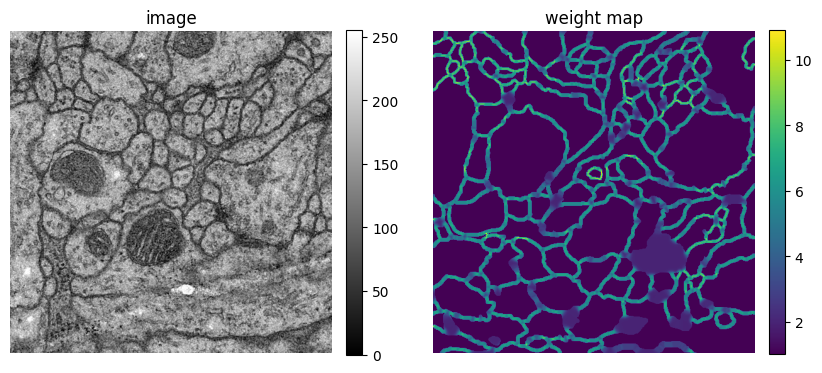

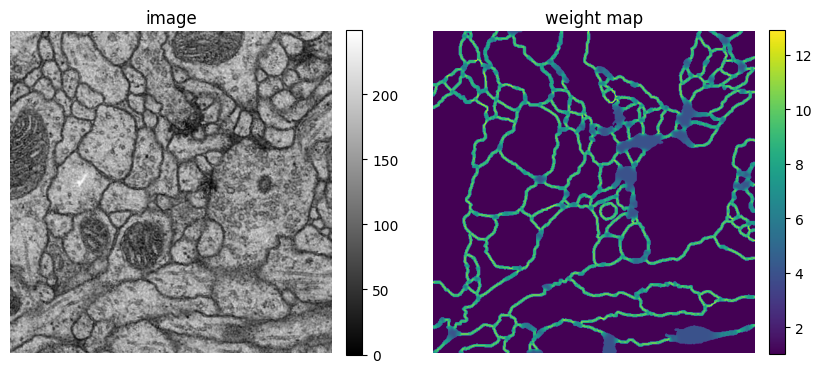

In [ ]:
# Parameters used by the authors
w0    = 10
sigma = 5

for i in np.random.randint(0, img_mtrx.shape[0], 2): # Randomly draw 3 images

    # Grab image and label map
    mask = mask_mtrx[i, :, :]
    img  = img_mtrx[i, :, :]

    # Compute weight map
    w = weight_map(mask = mask, w0 = w0, sigma = sigma)

    # Plot results
    fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 10));

    im = ax[0].imshow(img, 'gray')
    plt.colorbar(im, ax = ax[0], fraction = 0.046, pad = 0.04)
    ax[0].axis('off')
    ax[0].set_title('image')

    im = ax[1].imshow(w)
    plt.colorbar(im, ax = ax[1], fraction = 0.046, pad = 0.04)
    ax[1].axis('off');
    ax[1].set_title('weight map');

Very good

### Data Augmentation

According to the authors we need:
Shift and rotation invariance as well as robustness to deformations and gray value variations.
Especially random elastic deformations of the training samples were found to be the key concept to train a segmentation network with very few annotated images.

Let's define the transformations:

In [ ]:
# Define augmentation pipelines
p = 0.95
train_transform = A.Compose([
    A.OneOf([
        A.HorizontalFlip(p = p),
        A.VerticalFlip(p = p),
        A.Transpose(p = p),
        A.RandomRotate90(p = p),
        A.ShiftScaleRotate(p = p, shift_limit = 0.0625, scale_limit = 0.1, rotate_limit = 45)
    ], p = 1),
    A.GaussNoise(p = p, var_limit = (0, 20), mean = 0, per_channel = True),
    A.MultiplicativeNoise(p = p, multiplier=(0.9, 1.1), elementwise = True),
    A.ElasticTransform(p = p, alpha = 35, sigma = 5, alpha_affine = 3, approximate = True),
    A.RandomBrightnessContrast(p = p, brightness_limit = 0.15, contrast_limit = 0.15),
    A.PadIfNeeded(p = 1, min_height = 128, min_width = 128, border_mode = cv2.BORDER_REFLECT)
])


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_36/295515641.py:11: UserWarning: Argument(s) 'var_limit, mean' are not valid for transform GaussNoise
  A.GaussNoise(p = p, var_limit = (0, 20), mean = 0, per_channel = True),
/tmp/ipykernel_36/295515641.py:13: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(p = p, alpha = 35, sigma = 5, alpha_affine = 3, approximate = True),


Let's have a look:

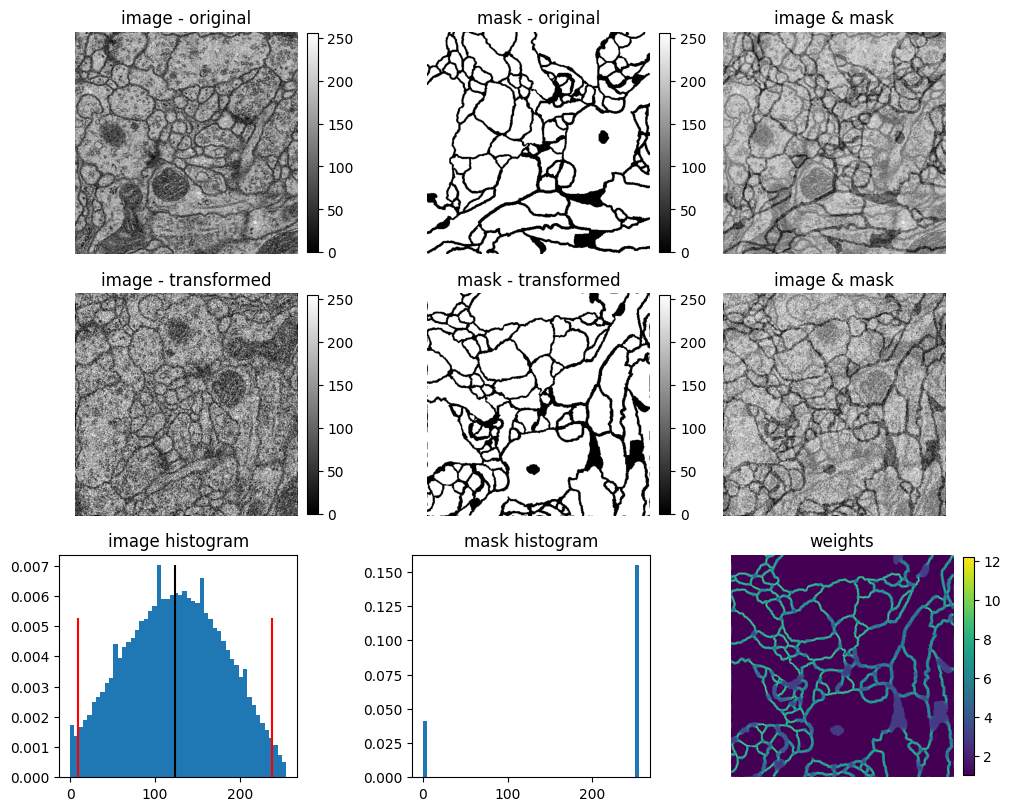

In [ ]:
# Parameters recommended by the authors
w0   = 10
sigma = 5

for i in np.random.randint(0, 30, 1): # Randomly draw 1 image

    # Grab image and label map
    mask = mask_mtrx[i, :, :]
    img  = img_mtrx[i, :, :]

    # Apply transformations
    aug     = train_transform(image = img, mask = mask)
    img_t   = aug["image"]
    mask_t  = aug["mask"]

    # Compute weight map
    weights = weight_map(mask = mask_t, w0 = w0, sigma = sigma)

    # Plot
    fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (10,8), constrained_layout=True)

    im = ax[0, 0].imshow(img, 'gray', interpolation = None)
    plt.colorbar(im, ax = ax[0, 0], fraction = 0.046, pad = 0.04)
    ax[0, 0].axis('off');
    ax[0, 0].set_title('image - original')

    im = ax[0, 1].imshow(mask, 'gray', interpolation = None)
    plt.colorbar(im, ax = ax[0, 1], fraction = 0.046, pad = 0.04)
    ax[0, 1].axis('off');
    ax[0, 1].set_title('mask - original')

    ax[0, 2].imshow(img, 'gray', interpolation = None)
    ax[0, 2].imshow(mask, 'gray', interpolation = None, alpha = 0.3)
    ax[0, 2].axis('off');
    ax[0, 2].set_title('image & mask')

    im = ax[1, 0].imshow(img_t, 'gray', interpolation = None)
    plt.colorbar(im, ax = ax[1, 0], fraction = 0.046, pad = 0.04)
    ax[1, 0].axis('off');
    ax[1, 0].set_title('image - transformed')

    im = ax[1, 1].imshow(mask_t, 'gray', interpolation = None)
    plt.colorbar(im, ax = ax[1, 1], fraction = 0.046, pad = 0.04)
    ax[1, 1].axis('off');
    ax[1, 1].set_title('mask - transformed')

    ax[1, 2].imshow(img_t, 'gray', interpolation = None)
    ax[1, 2].imshow(mask_t, 'gray', interpolation = None, alpha = 0.3)
    ax[1, 2].axis('off');
    ax[1, 2].set_title('image & mask')

    counts, _, _ = ax[2, 0].hist(img_t.reshape(-1, 1), bins = 50, density = True);
    ax[2, 0].vlines(img_t.mean(), 0, max(counts), colors='k')
    ax[2, 0].vlines(img_t.mean() + 2 * np.std(img_t), 0, max(counts) * 0.75, colors='r')
    ax[2, 0].vlines(img_t.mean() - 2 * np.std(img_t), 0, max(counts) * 0.75, colors='r')
    ax[2, 0].set_title('image histogram')

    ax[2, 1].hist(mask_t.reshape(-1, 1), bins = 50, density = True);
    ax[2, 1].set_title('mask histogram')

    im = ax[2, 2].imshow(weights, interpolation = None)
    plt.colorbar(im, ax = ax[2, 2], fraction = 0.046, pad = 0.04)
    ax[2, 2].axis('off');
    ax[2, 2].set_title('weights')

In [ ]:
class WeightedBCEWithLogitsLoss(nn.Module):
    ''' Pixel-wise weighted BCEWithLogitsLoss'''

    def __init__(self, batch_size):

        super().__init__()
        self.batch_size = batch_size
        self.unw_loss = nn.BCEWithLogitsLoss(reduction = 'none')

    def __call__(self, true, predicted, weights):

        # Compute weighted loss
        loss = self.unw_loss(predicted, true) * weights

        # Sum over all channels
        loss = loss.sum(dim = 1)

        # Flatten and rescale so that loss is approx. in the same interval
        loss = loss.view(self.batch_size, -1) / weights.view(self.batch_size, -1)

        # Average over mini-batch
        loss = loss.mean()

        return loss


class SegmentationDataset(Dataset):

    def __init__(self, images, masks, wmap_w0, wmap_sigma, device, transform = None):
        ''' Initialisation function '''

        self.images    = images
        self.masks     = masks
        self.transform = transform
        self.device    = device

        # Parameters for weight map calculation
        self.w0    = wmap_w0
        self.sigma = wmap_sigma

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        ''' Preprocess and return image, mask, and weight map '''

        image = self.images[idx, :, :]
        mask  = self.masks[idx, :, :]

        if self.transform:

            # Apply transformations
            aug   = self.transform(image = image, mask  = mask)
            image = aug["image"]
            mask  = aug["mask"]

        # Compute weight map
        weights = weight_map(mask = mask, w0 = self.w0, sigma = self.sigma)

        # Min-max scale image and mask
        image = self.min_max_scale(image, min_val = 0, max_val = 1)
        mask  = self.min_max_scale(mask,  min_val = 0, max_val = 1)

        # Add channel dimensions
        image   = np.expand_dims(image,   axis = 0)
        weights = np.expand_dims(weights, axis = 0)
        mask    = np.expand_dims(mask,    axis = 0)

        # Convert to tensors and send to device
        weights = torch.from_numpy(weights).double().to(self.device)
        image   = torch.from_numpy(image).double().to(self.device)
        mask    = torch.from_numpy(mask).double().to(self.device)

        # Center crop mask and weights (negative padding = cropping - size defined manually)
        mask    = nn.ZeroPad2d(-94)(mask)
        weights = nn.ZeroPad2d(-94)(weights)

        return image, mask, weights

    @staticmethod
    def min_max_scale(image, max_val, min_val):
        '''Normalization to range of min, max'''

        image_new = (image - np.min(image)) * (max_val - min_val) / (np.max(image) - np.min(image)) + min_val
        return image_new

### Training Loop

Now, we can put everything together. The authors report average performance over 7 rotations of the dataset. We'll just do one here to save time:

In [ ]:
def train_step(model, data_loader, loss_fn, accumulation_steps, optimizer, device):

    model.train()

    train_loss, train_acc = 0, 0
    for batch_id, (X, y, weights) in tqdm(enumerate(data_loader), leave=False):

        X, y, weights = X.to(device), y.to(device), weights.to(device)

        y_pred = model(X)
        y_pred = F.interpolate(y_pred, y.shape[-2:])

        loss = loss_fn(y_pred, y, weights) / accumulation_steps
        train_loss += loss.item()
        loss.backward()

        if ( (batch_id + 1) % accumulation_steps == 0
            or (batch_id + 1) == len(data_loader) ):
            optimizer.step()
            optimizer.zero_grad()


    return train_loss / len(data_loader)


def test_step(model, data_loader, loss_fn, device):

    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch_id, (X, y, weights) in enumerate(data_loader):

            X, y, weights = X.to(device), y.to(device), weights.to(device)

            y_pred = model(X)
            y_pred = F.interpolate(y_pred, y.shape[-2:])

            loss = loss_fn(y_pred, y, weights)
            test_loss += loss.item()

            y_hat = torch.sigmoid(y_pred)

            # Convert to numpy
            X = np.squeeze(X.cpu().numpy())
            y = np.squeeze(y.cpu().numpy())
            w = np.squeeze(weights.cpu().numpy())
            y_hat = np.squeeze(y_hat.detach().cpu().numpy())

            # Make mask
            y_hat2 = y_hat > 0.5

            # plot
            fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 8))

            ax[0].imshow(y, 'gray', interpolation = None)
            ax[0].axis('off');
            ax[0].set_title('Target');

            ax[1].imshow(y_hat, 'gray', interpolation = None)
            ax[1].axis('off');
            ax[1].set_title('Prediction');
            plt.show()


    return test_loss / len(data_loader)

def train(model,
          train_data_loader,
          test_data_loader,
          accumulation_steps,
          test_every,
          optimizer,
          loss_fn,
          epochs,
          device):

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
        }

    model.to(device)

    for epoch in tqdm(range(epochs)):

        start_time = timer()
        train_loss = train_step(
            model=model,
            data_loader=train_data_loader,
            accumulation_steps=accumulation_steps,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )
        end_time = timer()
        if epoch % test_every == 0:
            test_loss = test_step(
                model=model,
                data_loader=test_data_loader,
                loss_fn=loss_fn,
                device=device,
            )

        results["train_loss"].append(train_loss)
        results["test_loss"].append(test_loss)

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"time: {(end_time-start_time):.4f}"
        )

    return results

  0%|          | 0/30 [00:00<?, ?it/s]

0it [00:00, ?it/s]

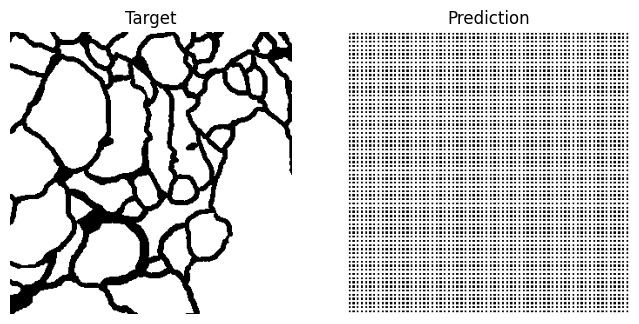

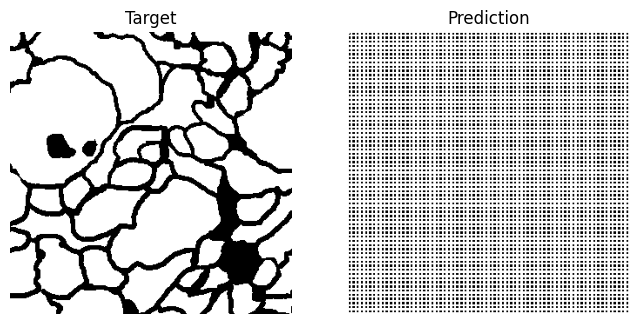

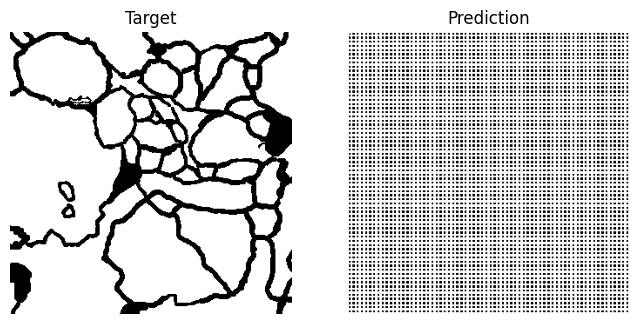

Epoch: 1 | train_loss: 0.0340 | test_loss: -260277761.7844 | time: 247.7313


0it [00:00, ?it/s]

Epoch: 2 | train_loss: 0.0282 | test_loss: -260277761.7844 | time: 210.1115


0it [00:00, ?it/s]

Epoch: 3 | train_loss: 0.0189 | test_loss: -260277761.7844 | time: 214.7271


0it [00:00, ?it/s]

Epoch: 4 | train_loss: 0.0092 | test_loss: -260277761.7844 | time: 214.4873


0it [00:00, ?it/s]

Epoch: 5 | train_loss: -0.0009 | test_loss: -260277761.7844 | time: 214.0489


0it [00:00, ?it/s]

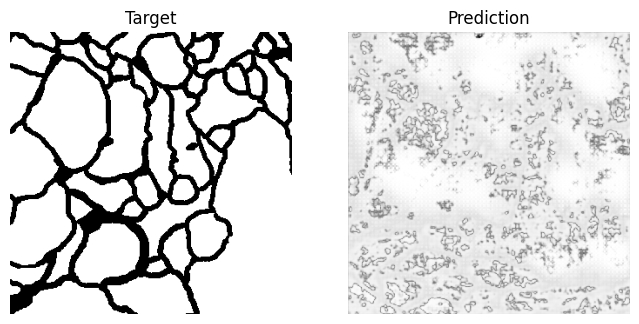

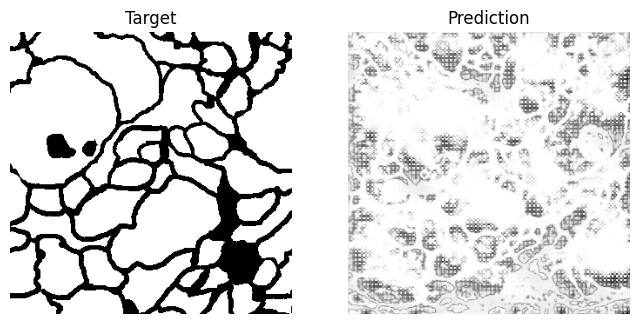

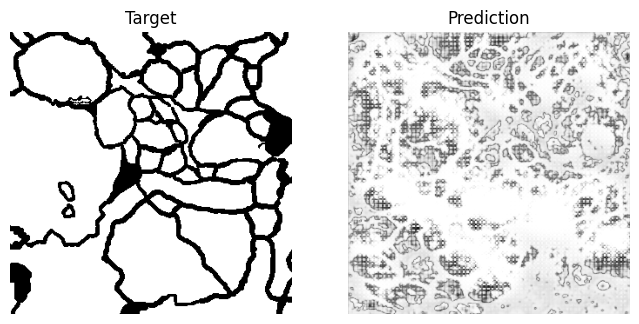

Epoch: 6 | train_loss: -0.0102 | test_loss: -1.6165 | time: 213.8243


0it [00:00, ?it/s]

Epoch: 7 | train_loss: -0.0183 | test_loss: -1.6165 | time: 209.5063


0it [00:00, ?it/s]

Epoch: 8 | train_loss: -0.0262 | test_loss: -1.6165 | time: 213.4713


0it [00:00, ?it/s]

Epoch: 9 | train_loss: -0.0340 | test_loss: -1.6165 | time: 214.3218


0it [00:00, ?it/s]

Epoch: 10 | train_loss: -0.0418 | test_loss: -1.6165 | time: 213.8917


0it [00:00, ?it/s]

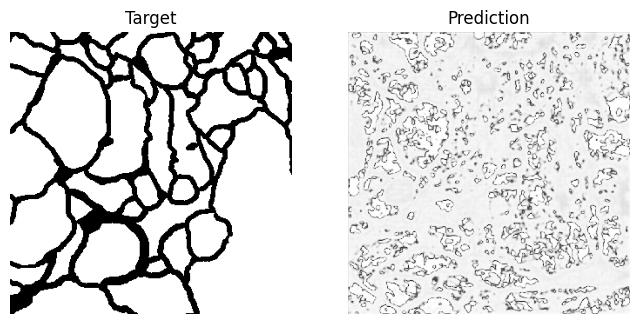

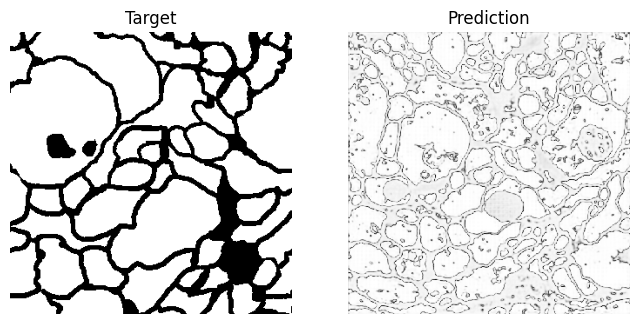

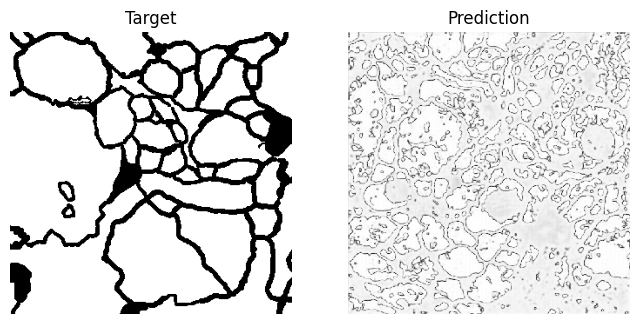

Epoch: 11 | train_loss: -0.0504 | test_loss: -2.0225 | time: 214.7729


0it [00:00, ?it/s]

Epoch: 12 | train_loss: -0.0588 | test_loss: -2.0225 | time: 209.6020


0it [00:00, ?it/s]

Epoch: 13 | train_loss: -0.0674 | test_loss: -2.0225 | time: 214.4443


0it [00:00, ?it/s]

Epoch: 14 | train_loss: -0.0776 | test_loss: -2.0225 | time: 214.3530


0it [00:00, ?it/s]

Epoch: 15 | train_loss: -0.0884 | test_loss: -2.0225 | time: 214.7764


0it [00:00, ?it/s]

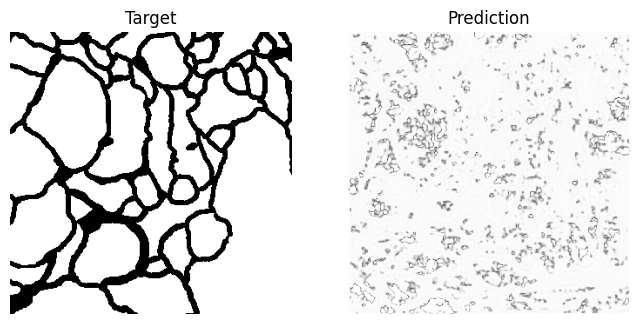

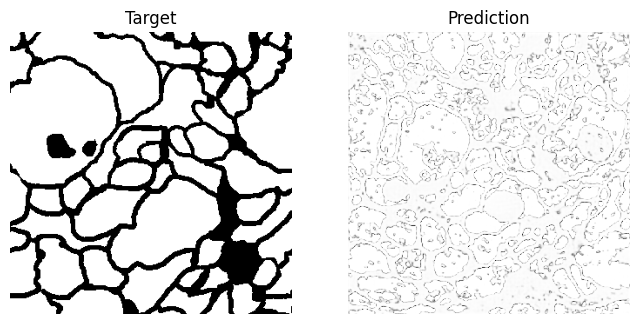

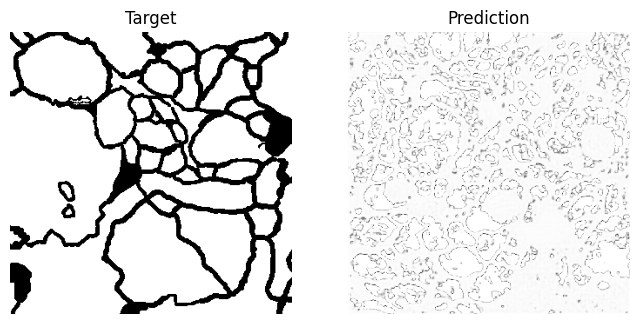

Epoch: 16 | train_loss: -0.0985 | test_loss: -3.2391 | time: 214.1351


0it [00:00, ?it/s]

Epoch: 17 | train_loss: -0.1095 | test_loss: -3.2391 | time: 208.7997


0it [00:00, ?it/s]

Epoch: 18 | train_loss: -0.1209 | test_loss: -3.2391 | time: 214.1218


0it [00:00, ?it/s]

Epoch: 19 | train_loss: -0.1318 | test_loss: -3.2391 | time: 214.0823


0it [00:00, ?it/s]

Epoch: 20 | train_loss: -0.1442 | test_loss: -3.2391 | time: 214.4787


0it [00:00, ?it/s]

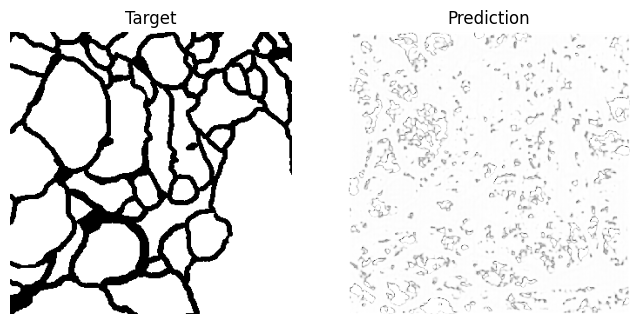

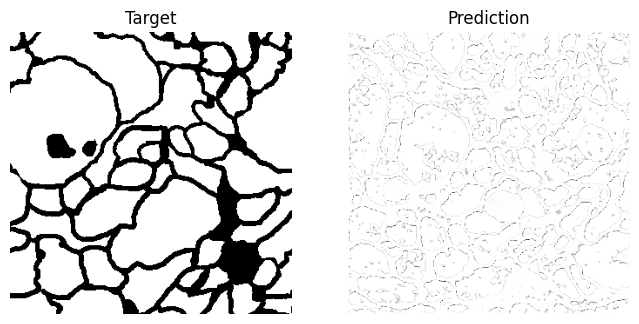

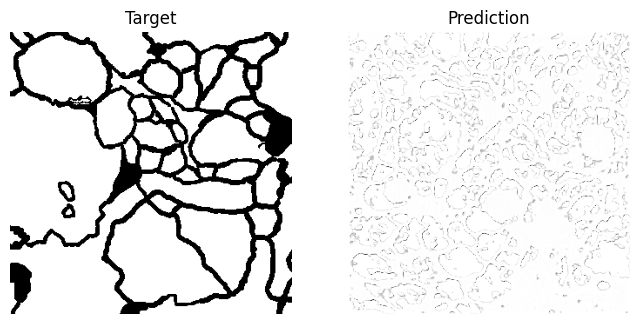

Epoch: 21 | train_loss: -0.1574 | test_loss: -4.8154 | time: 214.2669


0it [00:00, ?it/s]

Epoch: 22 | train_loss: -0.1705 | test_loss: -4.8154 | time: 209.4495


0it [00:00, ?it/s]

Epoch: 23 | train_loss: -0.1842 | test_loss: -4.8154 | time: 213.6254


0it [00:00, ?it/s]

Epoch: 24 | train_loss: -0.1982 | test_loss: -4.8154 | time: 214.7420


0it [00:00, ?it/s]

Epoch: 25 | train_loss: -0.2122 | test_loss: -4.8154 | time: 214.9469


0it [00:00, ?it/s]

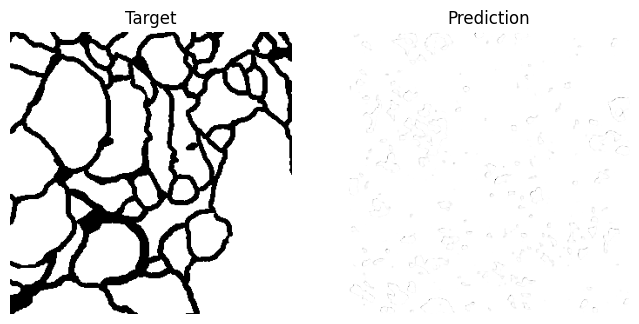

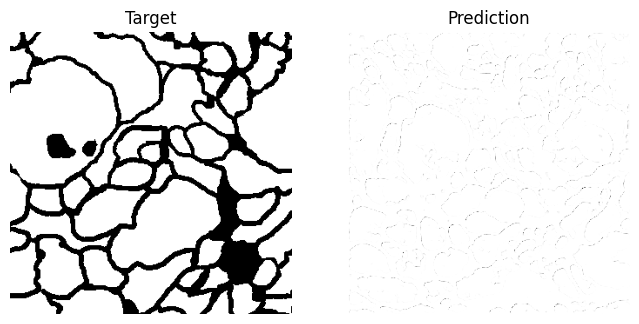

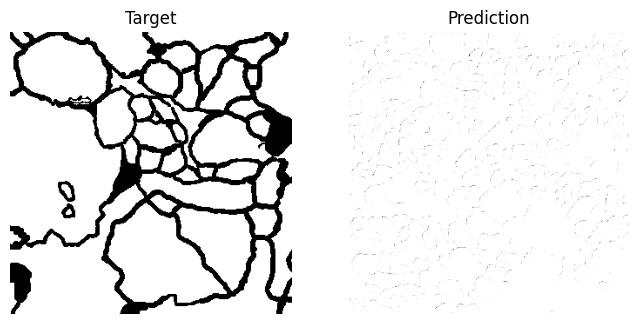

Epoch: 26 | train_loss: -0.2292 | test_loss: -8.3786 | time: 214.5201


0it [00:00, ?it/s]

Epoch: 27 | train_loss: -0.2441 | test_loss: -8.3786 | time: 209.5212


0it [00:00, ?it/s]

Epoch: 28 | train_loss: -0.2603 | test_loss: -8.3786 | time: 214.4148


0it [00:00, ?it/s]

Epoch: 29 | train_loss: -0.2774 | test_loss: -8.3786 | time: 214.3918


0it [00:00, ?it/s]

Epoch: 30 | train_loss: -0.2951 | test_loss: -8.3786 | time: 215.3899


In [ ]:
epochs             = 30   # 100-150 probablly in original paper
act_batch_size     = 1    # Can't fit more than one image in GPU!
learning_rate      = 1e-2 # probabbly a scheduler was used in the orginal paper
accumulation_steps = 32   # Efective batch (Gradient accumulation)
# Efective batch = act_batch_size * accumulation_steps
test_every         = 5
device             = 'cuda' if torch.cuda.is_available() else 'cpu'
channels           = C
w0                 = 10
sigma              = 5


# Configure train test split
np.random.seed(123)
no_img    = img_mtrx.shape[0]
test_idx  = np.random.randint(0, no_img, 3) # Keep 3 images for test set
train_idx = np.setdiff1d(np.arange(0, no_img), test_idx)

# Make datasets
train_set = SegmentationDataset(images    = img_mtrx[train_idx, :, :],
                                        masks     = mask_mtrx[train_idx, :, :],
                                        transform = train_transform,
                                        device = device, wmap_w0 = w0, wmap_sigma = sigma)

test_set = SegmentationDataset(images    = img_mtrx[test_idx, :, :],
                                        masks     = mask_mtrx[test_idx, :, :],
                                        transform = None,
                                        device = device, wmap_w0 = w0, wmap_sigma = sigma)

# Make dataloaders
train_loader = DataLoader(dataset     = train_set,
                          batch_size  = act_batch_size,
                          shuffle     = True,
                          num_workers = 0,     # Change to >0 for performance
                          pin_memory  = False) # Change to true for performance

test_loader  = DataLoader(dataset     = test_set,
                          batch_size  = 1,
                          shuffle     = False,
                          num_workers = 0,     # Change to >0 for performance
                          pin_memory  = False) # Change to true for performance

model = UNetSegmentation(in_channels = channels, no_classes = 1).double().to(device)

model = torch.compile(model)

optimizer = optim.AdamW(model.parameters(), lr = learning_rate)

criterion = WeightedBCEWithLogitsLoss(batch_size = act_batch_size)

results = train(model, train_loader, test_loader, accumulation_steps, test_every, optimizer, criterion, epochs, device)